In [1]:

# DISSERTATION ANALYSIS PIPELINE
# Run in Google Colab — upload your annotated Master_Annotation_File.csv first
# ============================================================
# CELL 1: Install and import everything
# ============================================================

!pip install textstat scikit-learn matplotlib seaborn spacy -q
!python -m spacy download en_core_web_sm -q

import pandas as pd
import numpy as np
import textstat
import spacy
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

nlp = spacy.load('en_core_web_sm')

print("✅ All libraries loaded")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 36.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 83.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ All libraries loaded


In [2]:
# ============================================================
# CELL 2: Load your annotated data
# ============================================================

# Upload your annotated file first:
# Click the folder icon → Upload → select Master_Annotation_File.csv

df = pd.read_csv('Master_Annotation_File.csv', sep=';')

# Clean the complexity label column — convert to numeric, drop any unlabelled rows
df['Complexity Label (1-3)'] = pd.to_numeric(df['Complexity Label (1-3)'], errors='coerce')
df = df.dropna(subset=['Complexity Label (1-3)'])
df['Complexity Label (1-3)'] = df['Complexity Label (1-3)'].astype(int)

print(f"✅ Loaded {len(df)} annotated paragraphs")
print(f"\nLabel distribution:")
print(df['Complexity Label (1-3)'].value_counts().sort_index())
print(f"\nTier distribution:")
print(df['Source Tier'].value_counts())
print(f"\nTheme distribution:")
print(df['Theme'].value_counts())

✅ Loaded 348 annotated paragraphs

Label distribution:
Complexity Label (1-3)
1    185
2    122
3     41
Name: count, dtype: int64

Tier distribution:
Source Tier
Third Sector          151
Local Council         111
Central Government     86
Name: count, dtype: int64

Theme distribution:
Theme
Financial Support             92
Benefits Eligibility          92
General Orientation           65
Housing & Homelessness        59
Immigration Status            23
Education & Training           7
Employment & Right to Work     5
Healthcare                     5
Name: count, dtype: int64


In [3]:


# ============================================================
# CELL 3: Define jargon dictionary
# These are welfare/benefits/immigration terms that a typical
# claimant (especially a refugee) would not know
# ============================================================

JARGON_TERMS = {
    # Benefits system jargon
    'universal credit', 'housing benefit', 'council tax', 'personal independence payment',
    'employment support allowance', 'jobseekers allowance', 'pension credit',
    'child benefit', 'child tax credit', 'working tax credit', 'benefit cap',
    'bedroom tax', 'spare room subsidy', 'local housing allowance',
    'discretionary housing payment', 'hardship payment', 'sanctions',
    'conditionality', 'claimant commitment', 'work capability assessment',
    'fit note', 'habitual residence test', 'right to reside',
    'recourse to public funds', 'no recourse to public funds', 'nrpf',
    'public funds', 'means-tested', 'means tested', 'non-contributory',
    'contributory', 'entitlement', 'eligible', 'eligibility',

    # Immigration/asylum jargon
    'leave to remain', 'indefinite leave to remain', 'ilr',
    'limited leave to remain', 'discretionary leave',
    'humanitarian protection', 'refugee status', 'subsidiary protection',
    'section 95', 'section 98', 'section 4', 'asylum support',
    'initial accommodation', 'dispersal accommodation', 'nass',
    'national asylum support service', 'home office', 'ukvi',
    'uk visas and immigration', 'biometric residence permit', 'brp',
    'national insurance number', 'ni number', 'right to work',
    'move-on period', 'move on period', '28-day', '28 day',
    'asylum seeker', 'asylum seekers', 'asylum claim', 'asylum application',
    'port of entry', 'screening interview', 'substantive interview',
    'fresh claim', 'further submissions', 'appeal', 'tribunal',

    # Housing jargon
    'social housing', 'temporary accommodation', 'homelessness duty',
    'priority need', 'intentionally homeless', 'local connection',
    'housing register', 'bidding', 'allocations', 'tenure',
    'assured shorthold tenancy', 'tenancy agreement', 'eviction',
    'possession order', 'section 21', 'deposit protection',

    # Legal/bureaucratic jargon
    'statutory', 'provision', 'regulation', 'pursuant', 'subsection',
    'schedule', 'tribunal', 'judicial review', 'mandatory reconsideration',
    'destitution', 'destitute', 'subsistence', 'dependant', 'dependants',
    'prescribed', 'designated', 'authorised', 'resided', 'ordinarily resident',
}

# Convert to list of individual words and phrases for matching
jargon_words = set()
jargon_phrases = set()
for term in JARGON_TERMS:
    if ' ' in term:
        jargon_phrases.add(term.lower())
    else:
        jargon_words.add(term.lower())

print(f"✅ Jargon dictionary: {len(JARGON_TERMS)} terms ({len(jargon_words)} words + {len(jargon_phrases)} phrases)")



✅ Jargon dictionary: 107 terms (35 words + 72 phrases)


In [4]:

# ============================================================
# CELL 4: Compute automated features for every paragraph
# ============================================================

def compute_features(text):
    """Compute linguistic complexity features for a single paragraph."""
    doc = nlp(text)

    # Basic stats
    words = [token.text for token in doc if not token.is_punct and not token.is_space]
    sentences = list(doc.sents)
    word_count = len(words)
    sent_count = len(sentences)

    if word_count == 0 or sent_count == 0:
        return {k: 0 for k in ['flesch_kincaid', 'dale_chall', 'avg_sentence_length',
                                'word_count', 'passive_voice_pct', 'jargon_density',
                                'avg_word_length', 'long_word_pct', 'noun_phrase_count',
                                'words_per_sentence_std']}

    # --- Readability scores ---
    flesch_kincaid = textstat.flesch_kincaid_grade(text)
    dale_chall = textstat.dale_chall_readability_score(text)

    # --- Sentence-level features ---
    avg_sentence_length = word_count / sent_count
    sent_lengths = [len([t for t in s if not t.is_punct and not t.is_space]) for s in sentences]
    words_per_sentence_std = np.std(sent_lengths) if len(sent_lengths) > 1 else 0

    # --- Word-level features ---
    avg_word_length = np.mean([len(w) for w in words]) if words else 0
    long_word_pct = sum(1 for w in words if len(w) > 6) / word_count * 100

    # --- Passive voice detection ---
    passive_count = 0
    for token in doc:
        if token.dep_ == 'nsubjpass' or (token.dep_ == 'auxpass'):
            passive_count += 1
    passive_voice_pct = passive_count / sent_count * 100

    # --- Jargon density ---
    text_lower = text.lower()
    jargon_hits = 0
    # Check phrases first
    for phrase in jargon_phrases:
        if phrase in text_lower:
            jargon_hits += len(phrase.split())
    # Check individual words
    for word in words:
        if word.lower() in jargon_words:
            jargon_hits += 1
    jargon_density = jargon_hits / word_count * 100

    # --- Noun phrase complexity ---
    noun_phrase_count = len(list(doc.noun_chunks))

    return {
        'flesch_kincaid': round(flesch_kincaid, 2),
        'dale_chall': round(dale_chall, 2),
        'avg_sentence_length': round(avg_sentence_length, 2),
        'word_count': word_count,
        'passive_voice_pct': round(passive_voice_pct, 2),
        'jargon_density': round(jargon_density, 2),
        'avg_word_length': round(avg_word_length, 2),
        'long_word_pct': round(long_word_pct, 2),
        'noun_phrase_count': noun_phrase_count,
        'words_per_sentence_std': round(words_per_sentence_std, 2),
    }


# Compute features for all paragraphs
print("Computing features for all paragraphs... (this may take 2-3 minutes)")
features_list = []
for i, row in df.iterrows():
    if i % 50 == 0:
        print(f"  Processing paragraph {i+1}/{len(df)}...")
    features = compute_features(row['Paragraph Text'])
    features_list.append(features)

features_df = pd.DataFrame(features_list)
df = pd.concat([df.reset_index(drop=True), features_df], axis=1)

print(f"\n✅ Features computed for {len(df)} paragraphs")
print(f"\nFeature summary:")
print(features_df.describe().round(2))


Computing features for all paragraphs... (this may take 2-3 minutes)
  Processing paragraph 1/348...
  Processing paragraph 51/348...
  Processing paragraph 101/348...
  Processing paragraph 151/348...
  Processing paragraph 201/348...
  Processing paragraph 251/348...
  Processing paragraph 301/348...

✅ Features computed for 348 paragraphs

Feature summary:
       flesch_kincaid  dale_chall  avg_sentence_length  word_count  \
count          348.00      348.00               348.00      348.00   
mean            12.57       10.57                21.58      143.84   
std              7.28        1.91                10.60      146.97   
min              2.34        6.71                 6.00       15.00   
25%              9.32        9.32                15.15       46.00   
50%             11.60       10.42                19.81       95.00   
75%             14.27       11.64                24.85      180.00   
max            101.90       25.42                93.00     1056.00   

       

In [5]:

# ============================================================
# CELL 5: Descriptive statistics and 2×2 analysis
# ============================================================

print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)

# --- Overall label distribution ---
print("\n📊 Label distribution:")
label_dist = df['Complexity Label (1-3)'].value_counts().sort_index()
for label, count in label_dist.items():
    pct = count / len(df) * 100
    print(f"  Label {label}: {count} ({pct:.1f}%)")

# --- Mean complexity by tier ---
print("\n📊 Mean complexity by tier:")
tier_stats = df.groupby('Source Tier')['Complexity Label (1-3)'].agg(['mean', 'std', 'count'])
print(tier_stats.round(3).to_string())

# --- Mean complexity by theme ---
print("\n📊 Mean complexity by theme:")
theme_stats = df.groupby('Theme')['Complexity Label (1-3)'].agg(['mean', 'std', 'count'])
print(theme_stats.sort_values('mean', ascending=False).round(3).to_string())

# --- Mean automated features by tier ---
feature_cols = ['flesch_kincaid', 'dale_chall', 'avg_sentence_length',
                'passive_voice_pct', 'jargon_density', 'avg_word_length', 'long_word_pct']

print("\n📊 Mean features by tier:")
tier_features = df.groupby('Source Tier')[feature_cols].mean()
print(tier_features.round(2).to_string())

# --- THE 2×2 ANALYSIS (Theme × Tier) ---
print("\n" + "=" * 60)
print("2×2 ANALYSIS: MEAN COMPLEXITY BY THEME × TIER")
print("=" * 60)
pivot = df.pivot_table(
    values='Complexity Label (1-3)',
    index='Theme',
    columns='Source Tier',
    aggfunc=['mean', 'count']
)
print(pivot.round(2).to_string())

# Save descriptive stats to CSV
tier_stats.to_csv('Results_Tier_Stats.csv')
theme_stats.to_csv('Results_Theme_Stats.csv')
pivot.to_csv('Results_2x2_Analysis.csv')
print("\n✅ Statistics saved to CSV files")


DESCRIPTIVE STATISTICS

📊 Label distribution:
  Label 1: 185 (53.2%)
  Label 2: 122 (35.1%)
  Label 3: 41 (11.8%)

📊 Mean complexity by tier:
                     mean    std  count
Source Tier                            
Central Government  1.826  0.754     86
Local Council       1.477  0.672    111
Third Sector        1.530  0.641    151

📊 Mean complexity by theme:
                             mean    std  count
Theme                                          
Financial Support           1.717  0.761     92
Benefits Eligibility        1.696  0.691     92
Housing & Homelessness      1.627  0.692     59
Healthcare                  1.600  0.894      5
Education & Training        1.429  0.787      7
Employment & Right to Work  1.400  0.548      5
General Orientation         1.354  0.571     65
Immigration Status          1.261  0.449     23

📊 Mean features by tier:
                    flesch_kincaid  dale_chall  avg_sentence_length  passive_voice_pct  jargon_density  avg_word_length  lo

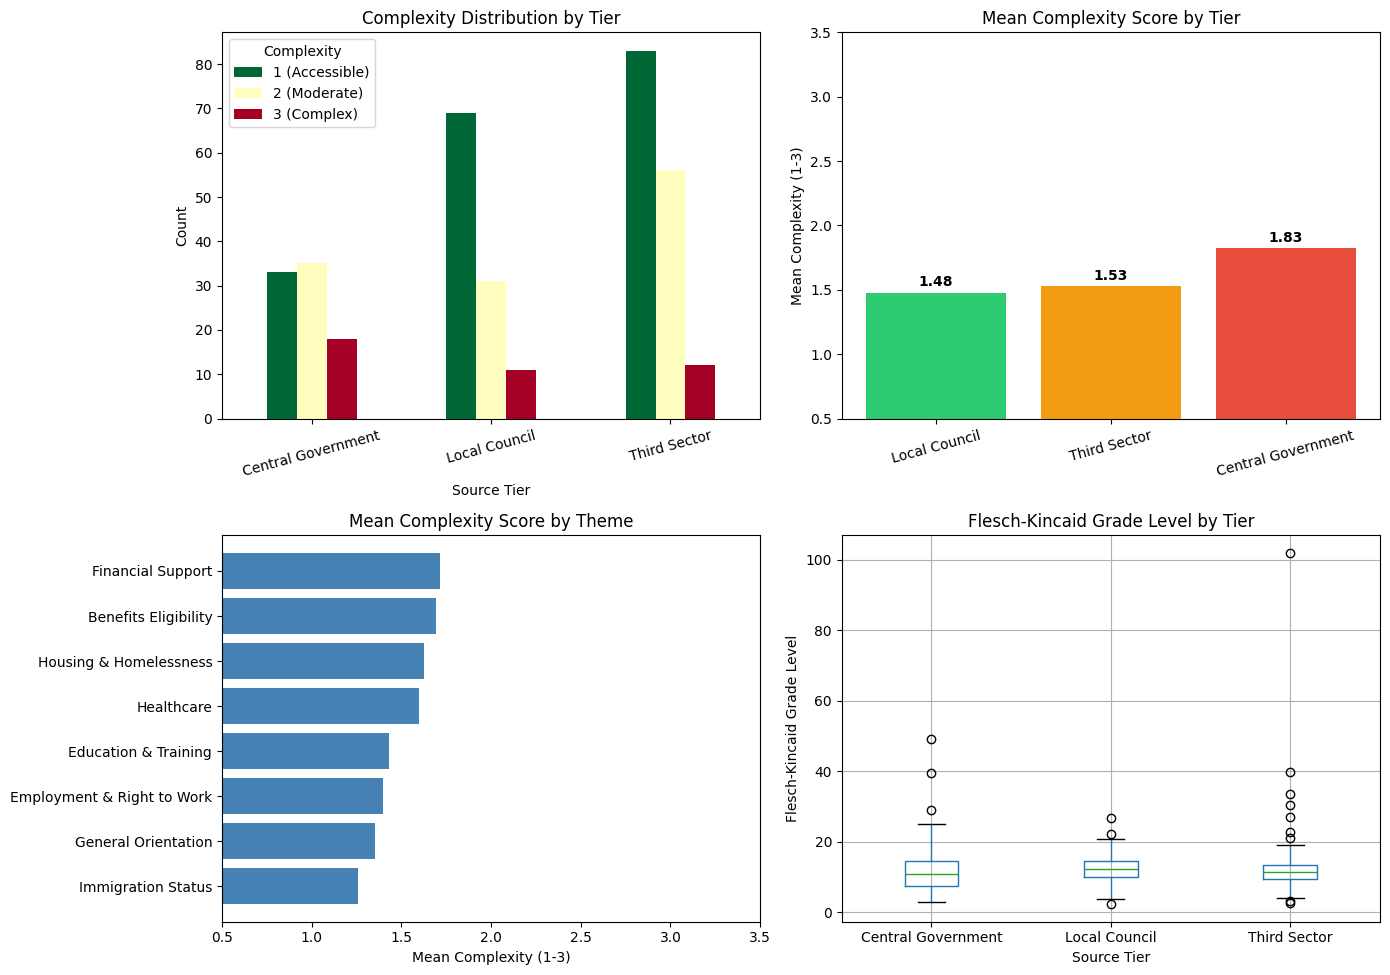

✅ Charts saved to Results_Charts.png


In [6]:

# ============================================================
# CELL 6: Visualisations
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Linguistic Complexity Analysis Results', fontsize=14, fontweight='bold')

# 1. Label distribution by tier
ax1 = axes[0, 0]
tier_label_counts = df.groupby(['Source Tier', 'Complexity Label (1-3)']).size().unstack(fill_value=0)
tier_label_counts.plot(kind='bar', ax=ax1, colormap='RdYlGn_r')
ax1.set_title('Complexity Distribution by Tier')
ax1.set_xlabel('Source Tier')
ax1.set_ylabel('Count')
ax1.legend(title='Complexity', labels=['1 (Accessible)', '2 (Moderate)', '3 (Complex)'])
ax1.tick_params(axis='x', rotation=15)

# 2. Mean complexity by tier
ax2 = axes[0, 1]
tier_means = df.groupby('Source Tier')['Complexity Label (1-3)'].mean().sort_values()
bars = ax2.bar(tier_means.index, tier_means.values, color=['#2ecc71', '#f39c12', '#e74c3c'])
ax2.set_title('Mean Complexity Score by Tier')
ax2.set_ylabel('Mean Complexity (1-3)')
ax2.set_ylim(0.5, 3.5)
for bar, val in zip(bars, tier_means.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.2f}', ha='center', fontweight='bold')
ax2.tick_params(axis='x', rotation=15)

# 3. Mean complexity by theme
ax3 = axes[1, 0]
theme_means = df.groupby('Theme')['Complexity Label (1-3)'].mean().sort_values(ascending=True)
ax3.barh(theme_means.index, theme_means.values, color='steelblue')
ax3.set_title('Mean Complexity Score by Theme')
ax3.set_xlabel('Mean Complexity (1-3)')
ax3.set_xlim(0.5, 3.5)

# 4. Flesch-Kincaid by tier (boxplot)
ax4 = axes[1, 1]
df.boxplot(column='flesch_kincaid', by='Source Tier', ax=ax4)
ax4.set_title('Flesch-Kincaid Grade Level by Tier')
ax4.set_xlabel('Source Tier')
ax4.set_ylabel('Flesch-Kincaid Grade Level')
plt.suptitle('')  # Remove default pandas title

plt.tight_layout()
plt.savefig('Results_Charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Charts saved to Results_Charts.png")


In [7]:

# ============================================================
# CELL 7: Train classifiers
# ============================================================

print("=" * 60)
print("CLASSIFIER TRAINING")
print("=" * 60)

# Features for the model
feature_names = ['flesch_kincaid', 'dale_chall', 'avg_sentence_length', 'word_count',
                 'passive_voice_pct', 'jargon_density', 'avg_word_length',
                 'long_word_pct', 'noun_phrase_count', 'words_per_sentence_std']

X = df[feature_names].values
y = df['Complexity Label (1-3)'].values

# Check we have enough data for each class
print(f"\nClass distribution: {dict(Counter(y))}")

# Train-test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {len(X_train)} paragraphs")
print(f"Test set: {len(X_test)} paragraphs")

# --- Train three models ---
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'SVM': SVC(kernel='rbf', random_state=42, class_weight='balanced'),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
}

results = {}
for name, model in models.items():
    print(f"\n--- {name} ---")

    # Use scaled features for SVM and LR, unscaled for RF
    if name == 'Random Forest':
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        cv_scores = cross_val_score(model, X, y, cv=5, scoring='f1_macro')
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        cv_scores = cross_val_score(model, scaler.fit_transform(X), y, cv=5, scoring='f1_macro')

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    print(f"Accuracy: {acc:.3f}")
    print(f"Macro F1: {f1:.3f}")
    print(f"5-Fold CV F1: {cv_scores.mean():.3f} (±{cv_scores.std():.3f})")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Accessible', 'Moderate', 'Complex']))

    results[name] = {'accuracy': acc, 'f1': f1, 'cv_f1': cv_scores.mean(), 'predictions': y_pred}

# --- Find best model ---
best_model_name = max(results, key=lambda k: results[k]['f1'])
print(f"\n🏆 Best model: {best_model_name} (F1: {results[best_model_name]['f1']:.3f})")



CLASSIFIER TRAINING

Class distribution: {np.int64(2): 122, np.int64(1): 185, np.int64(3): 41}
Training set: 278 paragraphs
Test set: 70 paragraphs

--- Random Forest ---
Accuracy: 0.600
Macro F1: 0.510
5-Fold CV F1: 0.492 (±0.063)

Classification Report:
              precision    recall  f1-score   support

  Accessible       0.70      0.76      0.73        37
    Moderate       0.46      0.48      0.47        25
     Complex       0.50      0.25      0.33         8

    accuracy                           0.60        70
   macro avg       0.55      0.50      0.51        70
weighted avg       0.59      0.60      0.59        70


--- SVM ---
Accuracy: 0.500
Macro F1: 0.444
5-Fold CV F1: 0.408 (±0.071)

Classification Report:
              precision    recall  f1-score   support

  Accessible       0.72      0.57      0.64        37
    Moderate       0.41      0.44      0.42        25
     Complex       0.21      0.38      0.27         8

    accuracy                           0.50    

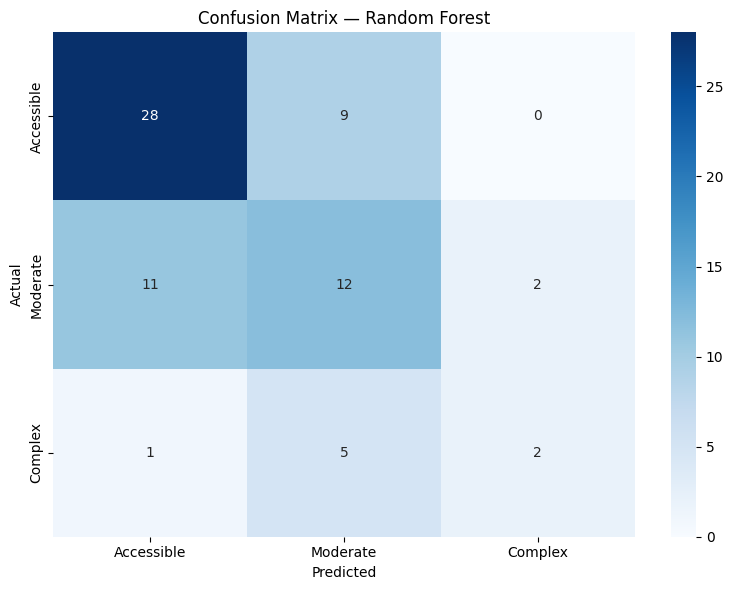

✅ Confusion matrix saved


In [8]:

# ============================================================
# CELL 8: Confusion matrix for best model
# ============================================================

best_preds = results[best_model_name]['predictions']

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Accessible', 'Moderate', 'Complex'],
            yticklabels=['Accessible', 'Moderate', 'Complex'])
ax.set_title(f'Confusion Matrix — {best_model_name}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('Results_Confusion_Matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved")


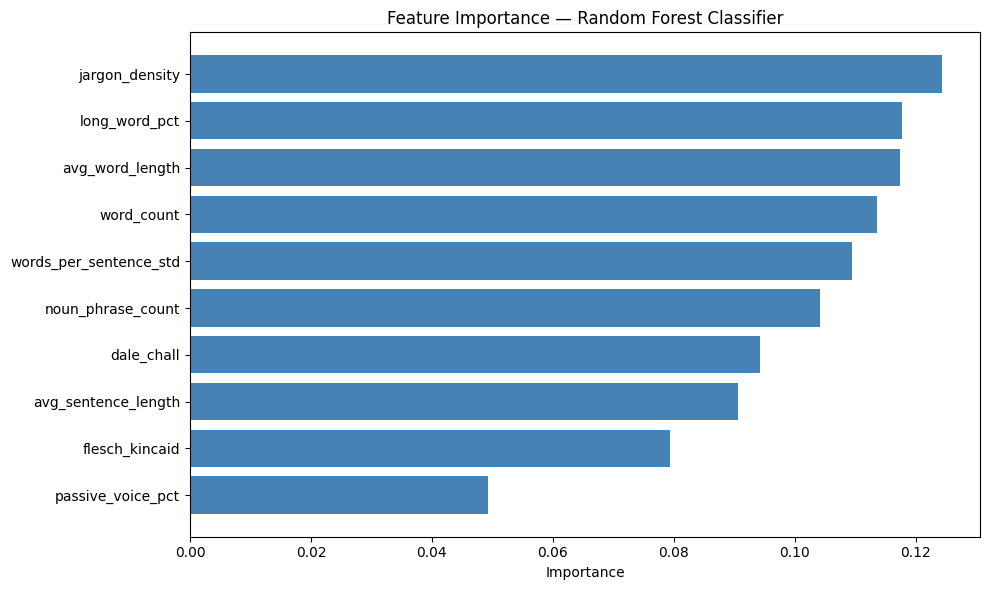


📊 Feature importance ranking:
  jargon_density: 0.1244
  long_word_pct: 0.1177
  avg_word_length: 0.1173
  word_count: 0.1135
  words_per_sentence_std: 0.1095
  noun_phrase_count: 0.1042
  dale_chall: 0.0942
  avg_sentence_length: 0.0905
  flesch_kincaid: 0.0794
  passive_voice_pct: 0.0493
✅ Feature importance chart saved


In [9]:

# ============================================================
# CELL 9: Feature importance (Random Forest)
# ============================================================

rf_model = models['Random Forest']
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
ax.set_title('Feature Importance — Random Forest Classifier')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('Results_Feature_Importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Feature importance ranking:")
for _, row in importance_df.sort_values('Importance', ascending=False).iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

print("✅ Feature importance chart saved")


In [10]:

# ============================================================
# CELL 10: Model comparison summary + save all results
# ============================================================

print("\n" + "=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)

comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'Macro F1': [results[m]['f1'] for m in results],
    '5-Fold CV F1': [results[m]['cv_f1'] for m in results],
})
print(comparison.to_string(index=False))
comparison.to_csv('Results_Model_Comparison.csv', index=False)

# Save the full dataset with features for reference
df.to_csv('Full_Dataset_With_Features.csv', index=False)

print(f"\n✅ ALL RESULTS SAVED:")
print(f"  - Results_Tier_Stats.csv")
print(f"  - Results_Theme_Stats.csv")
print(f"  - Results_2x2_Analysis.csv")
print(f"  - Results_Model_Comparison.csv")
print(f"  - Results_Charts.png")
print(f"  - Results_Confusion_Matrix.png")
print(f"  - Results_Feature_Importance.png")
print(f"  - Full_Dataset_With_Features.csv")
print(f"\n📋 Download all Results_* files for your dissertation write-up!")


MODEL COMPARISON SUMMARY
              Model  Accuracy  Macro F1  5-Fold CV F1
      Random Forest       0.6  0.510398      0.492084
                SVM       0.5  0.444056      0.407630
Logistic Regression       0.4  0.339018      0.331786

✅ ALL RESULTS SAVED:
  - Results_Tier_Stats.csv
  - Results_Theme_Stats.csv
  - Results_2x2_Analysis.csv
  - Results_Model_Comparison.csv
  - Results_Charts.png
  - Results_Confusion_Matrix.png
  - Results_Feature_Importance.png
  - Full_Dataset_With_Features.csv

📋 Download all Results_* files for your dissertation write-up!
